# DBSCAN Example: Classifying Running Backs by Size

In this notebook we will leverage the unsupervised algorithm DBSCAN to identify both running back size clusters. 

By conducting this analysis we will be able to identify outliers and examine their production to see if unique running back builds succeed, or if there's a few standard builds that NFL teams want.

In [9]:
# Import necessary libraries
import sys
import os

# Send Python to the project root so we can import our library
project_root = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/src"
sys.path.append(project_root)

# Import our ML library and other necessary libraries
import rice_ml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
# Import the dataset
data_path = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/data/NFL_players.csv"
data = pd.read_csv(data_path)

We now have the dataset and packages loaded for the analysis, so we can move on to preparation and cleaning.

In [11]:
# Only looking at running backs for this example
data = data[data["position"] == "RB"]

# Only want player identifiers and their height and weight
data = data[["display_name", "height", "weight"]]

# Drop any rows with missing data
data = data.dropna()

# View the first few rows of the dataset
print(data.head())

          display_name  height  weight
1    Israel Abanikanda    70.0   216.0
7       Ameer Abdullah    69.0   203.0
11      Rabih Abdullah    72.0   235.0
14  Walter Abercrombie    72.0   207.0
30         Josh Abrams    72.0   195.0


After filtering out all non-RBs, selecting the necessary columns, and dropping any rows with missing values, we have the data necessary for our analysis. 

In the small group we see above, the heights vary much less than the weights. We hypothesize that weight will be what truly separates running back classes as height is much less variable.

In the NFL we see all types of running backs and we think the weight is more influential in defining their play style because it determines their ability to hit and be hit. 

SCAT backs are smaller, lighter, elusive running backs defined by their very light weight and typically shorter height. 

Power backs can come in all heights, but are strictly heavier guys. Derrick Henry is a 6'3, 250 pound power back with great speed. Conversely, Mike Tolbert was just 5'9, but weighed 250 pounds, giving him the ability to be a power runner like Henry.

It's examples like this that make use think weight will be a bigger separator in terms of running back type.

In [12]:
# Standardize the height and weight data using our ML library's StandardScaler
scaler = rice_ml.StandardScaler()
X_scaled = scaler.fit_transform(data[["height", "weight"]].values)

Now that we have standardized the data we will use the K-Distance Elbow Method to find the right value for the EPS parameter for DBSCAN. We will set our minimum sample parameter to 200 because we have over 2400 running backs in our dataset and we don't want our clusters to be hyperspecific, very small groups of players.

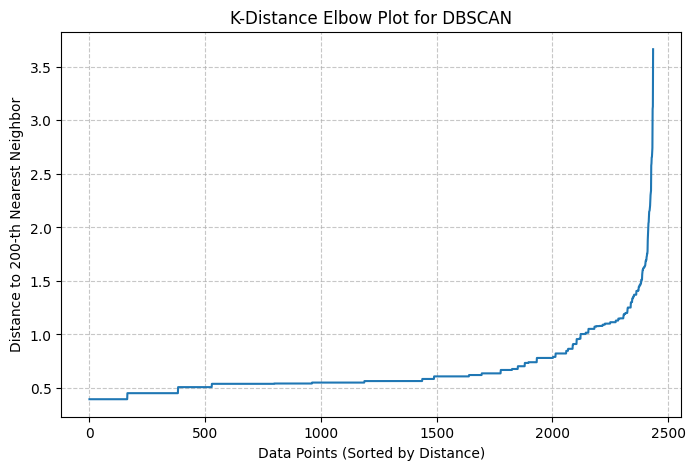

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Define k as min_samples for DBSCAN
k = 200

# Calculate the distances to the k-th nearest neighbor for each point
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to the k-th nearest neighborfor the K-Distance Graph
k_distances = distances[:, -1]
k_distances = np.sort(k_distances)

# Plot the K-Distance Graph
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Data Points (Sorted by Distance)")
plt.ylabel(f"Distance to {k}-th Nearest Neighbor")
plt.title("K-Distance Elbow Plot for DBSCAN")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

This plot is used to determine the value for the model parameter EPS. We are looking for the point where the staircasing pattern stops. We can see this is where the distance is at about 0.6, so we set EPS equal to 0.6.

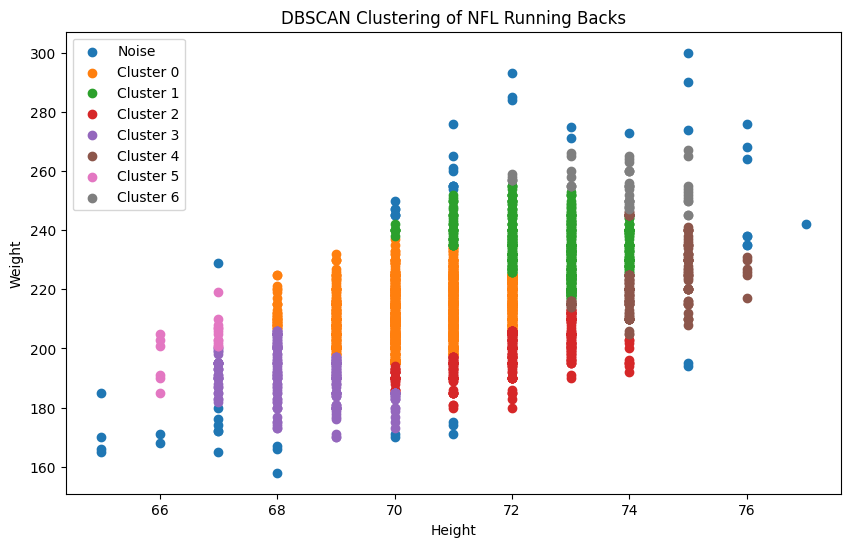

In [14]:
# Use our ML library to perform DBSCAN clustering on the height and weight of the players
dbscan = rice_ml.DBSCAN(eps=1.2, min_samples=200)
dbscan.train(X_scaled)

# Extract cluster labels for each player and add them to the original dataframe
clusters = dbscan.predict(X_scaled)
data["cluster"] = clusters

# Plot the clusters
plt.figure(figsize=(10, 6))

for cluster in np.unique(clusters):
    cluster_data = data[data["cluster"] == cluster]
    label_name = "Noise" if cluster == -1 else f"Cluster {cluster}"
    plt.scatter(cluster_data["height"], cluster_data["weight"], label=label_name)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("DBSCAN Clustering of NFL Running Backs")
plt.legend()
plt.show()

This plot displays that our DBSCAN model was able to identify seven clusters of running backs along with running backs who don't fit into any of the clusters. 

In [18]:
# Show separate dataframes for each cluster just the head of each cluster to avoid overwhelming output
for cluster in np.unique(clusters):
    cluster_data = data[data["cluster"] == cluster]
    cluster_data_display = cluster_data[["display_name", "height", "weight"]].round(1)
    print(f"Cluster {cluster} (Count: {len(cluster_data)})")
    print(cluster_data_display.head())
    print("-" * 40)

Cluster -1 (Count: 55)
         display_name  height  weight
63        David Adams    66.0   168.0
148         Ray Agnew    70.0   247.0
205      Ira Albright    72.0   285.0
507     Otis Anderson    71.0   174.0
1042  Warren Bankston    76.0   235.0
----------------------------------------
Cluster 0 (Count: 1161)
          display_name  height  weight
1    Israel Abanikanda    70.0   216.0
7       Ameer Abdullah    69.0   203.0
14  Walter Abercrombie    72.0   207.0
56        Curtis Adams    71.0   198.0
57          D.J. Adams    70.0   210.0
----------------------------------------
Cluster 1 (Count: 450)
          display_name  height  weight
11      Rabih Abdullah    72.0   235.0
68        George Adams    73.0   225.0
143        Tommie Agee    72.0   235.0
224  Charles Alexander    73.0   224.0
241     Jeff Alexander    72.0   245.0
----------------------------------------
Cluster 2 (Count: 327)
          display_name  height  weight
30         Josh Abrams    72.0   195.0
160       

By looking at some of the names and utilizing the plot above, we can name the clusters specific to how the model identified the group.

Cluster -1 is the noise cluster. These are players who are outliers in their relative weight or height, or both. David Adams is an extreme example of a scat back as he was just 5'6, 168 pounds, while Ira Albright is extremely heavy at 285 pounds. Otis Anderson is very light relative to other 5'11 players, while Ray Agnew is heavy for 5'10 backs. 

Cluster 0, the biggest cluster by far, appears to be our versatile backs. They are pretty average in terms of both height and weight, allowing them to play a variety of roles and potentially be a three down back.

Cluster 1 is one of our more power back groups. These players have fairly proportional height and weight but are above average in both, allowing them to thrive as effective as downhill, power runners.

Cluster 2 is a group of players slightly above average in height and slightly below average weight. They likely lean on their height to give help them with their vision, rather than bullying their way to yards. 

Cluster 3 is our lighter, smaller, likely speedier group. They aren't so small that they reach scat back level, but they are more likely to be used to get to the edge and, if they have the skills, as pass catchers. De'Von Achane is a prime example of this type of player because while he is a high volume guy, most of his work comes on the outside as both a runner and pass catcher. His weakness is his power, so the Dolphins have often used other running backs in his place when they are in short yardage situations.

Cluster 4 is a weird, uncommon group. These players are tall and skinny, a combination not often found in a running back.

Cluster 5 running backs are the scat backs. Being small and short creates a quickness and agility advantage, but a big disadvantage between the tackles and as a power runner. Tarik Cohen epitomizes this role as a gadget style player who didn't have the durability to be a three down guy. However, he was able to provide the Bears great explosiveness out of the backfield due to his elite quickness and change of direction.

Cluster 6 is the other power back cluster. These are the biggest and strongest backs who will always be looking to get downhill. Because of their size, they typically lack the speed to be a three down back, but can be extremely influential in high leverage, short yardage situations.

Ultimately the DBSCAN algorithm was effective in breaking down running back size groups. These size groups help identify how a running back should be used as size is significant in determining key traits like speed, strength, and durability.